<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>LLM Llama Recommendation hotel Airbnb</b></div>

![](https://img.freepik.com/vetores-gratis/conjunto-isometrico-de-hotel_1284-65100.jpg?t=st=1736210910~exp=1736214510~hmac=ef2615488b6c75258706df7b9a388d602063bfa106371129a4289c6e139ab198&w=826)

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 1 - Business Problem </b></div>

### Business Problem: Enhancing Hotel Recommendations Using LLMs

**Problem Statement:**
Travelers often face challenges when selecting the most suitable accommodation due to the overwhelming number of options available. The goal is to leverage a Large Language Model (LLM) such as LLaMA to provide personalized hotel recommendations based on user preferences. The system should consider various data points, including the description, amenities, neighborhood, and reviews, to ensure highly relevant and context-aware suggestions.

**Objective:**
Build a recommendation engine using LLaMA to deliver customized hotel suggestions based on user-provided inputs, such as travel purpose, budget, desired amenities, and location preferences. Use prompt engineering to extract valuable insights from the dataset and fine-tune the LLM's responses for accuracy and personalization.

### Business Impact:

1. **Improved User Experience:** Delivering highly personalized recommendations increases user satisfaction and booking rates.

2. **Higher Conversion Rates:** Recommending accommodations that align closely with user preferences reduces decision fatigue.

3. **Scalability:** Using LLaMA for recommendations enables seamless scaling across different regions and languages.

In [1]:
# Installing the latest versions of the Hugging Face Transformers library and Accelerate library
# Transformers: a library for natural language processing tasks like text classification, translation, etc.
# Accelerate: used to easily scale models across different hardware setups (CPU, GPU, multi-GPU, etc.)
# Install the bitsandbytes library
# bitsandbytes: a lightweight library that allows running large language models with fewer bits, enabling memory-efficient model training and inference.

# Installing packages
!pip install watermark
!pip install bitsandbytes
!pip install torch
!pip install spacy
!pip install langdetect
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 46.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993221 sha256=74c20862cf948c35337ee3d5c83399d58bbf6b52a9cb67d779d4a7300b996cf4
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.8 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting

In [2]:
# Import of libraries

# System libraries
import re
import unicodedata
import itertools
import string
from collections import Counter

# Library for file manipulation
import pandas as pd
import numpy as np
import pandas

# Data visualization
import seaborn as sns
import matplotlib.pylab as pl
import matplotlib as m
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import spacy
from spacy.lang.en.stop_words import STOP_WORDS as STOP_WORDS_EN  # English stopwords

# Load the English language model from spaCy
nlp_en = spacy.load('en_core_web_sm')

# Configuration for graph width and layout
sns.set_theme(style='whitegrid')
palette='viridis'

# Importing necessary libraries from PyTorch and Hugging Face Transformers
# PyTorch is a deep learning framework used for model training and inference
import torch  

# AutoTokenizer: Automatically loads a pre-trained tokenizer for encoding text
# AutoModelForCausalLM: Loads a pre-trained model for causal language modeling (e.g., for text generation)
# pipeline: Provides an easy-to-use interface to perform tasks like text generation, sentiment analysis, etc.
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Warnings remove alerts
import warnings
warnings.filterwarnings("ignore")

# Python version
from platform import python_version
print('Python version in this Jupyter Notebook:', python_version())

# Load library versions
import watermark

# Library versions
%reload_ext watermark
%watermark -a "Library versions" --iversions

# Download necessary resources from NLTK
import nltk
import spacy
nltk.download('punkt')  # Tokenizer models
nltk.download('stopwords')  # Stopwords data
nltk.download('wordnet')  # WordNet lemmatizer data

# Download Spacy language models for English
# English model
!python -m spacy download en_core_web_sm  

Python version in this Jupyter Notebook: 3.10.12
Author: Library versions

wordcloud   : 1.9.3
transformers: 4.47.1
spacy       : 3.7.6
seaborn     : 0.12.2
numpy       : 1.26.4
plotly      : 5.24.1
nltk        : 3.2.4
matplotlib  : 3.7.1
watermark   : 2.5.0
pandas      : 2.1.4
platform    : 1.0.8
re          : 2.2.1
torch       : 2.4.1+cu121

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
or

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 2 - Database </b></div>

In [3]:
# nrows=100
df = pd.read_csv("/kaggle/input/seattle/listings.csv")
df

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3813,8101950,https://www.airbnb.com/rooms/8101950,20160104002432,2016-01-04,3BR Mountain View House in Seattle,Our 3BR/2BA house boasts incredible views of t...,"Our 3BR/2BA house bright, stylish, and wheelch...",Our 3BR/2BA house boasts incredible views of t...,none,We're located near lots of family fun. Woodlan...,...,8.0,f,NaN,WASHINGTON,f,strict,f,f,8,0.30
3814,8902327,https://www.airbnb.com/rooms/8902327,20160104002432,2016-01-04,Portage Bay View!-One Bedroom Apt,800 square foot 1 bedroom basement apartment w...,This space has a great view of Portage Bay wit...,800 square foot 1 bedroom basement apartment w...,none,The neighborhood is a quiet oasis that is clos...,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,1,2.00
3815,10267360,https://www.airbnb.com/rooms/10267360,20160104002432,2016-01-04,Private apartment view of Lake WA,"Very comfortable lower unit. Quiet, charming m...",NaN,"Very comfortable lower unit. Quiet, charming m...",none,NaN,...,NaN,f,NaN,WASHINGTON,f,moderate,f,f,1,NaN
3816,9604740,https://www.airbnb.com/rooms/9604740,20160104002432,2016-01-04,Amazing View with Modern Comfort!,Cozy studio condo in the heart on Madison Park...,Fully furnished unit to accommodate most needs...,Cozy studio condo in the heart on Madison Park...,none,Madison Park offers a peaceful slow pace upsca...,...,NaN,f,NaN,WASHINGTON,f,moderate,f,f,1,NaN


In [4]:
df.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [5]:
df.tail()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
3813,8101950,https://www.airbnb.com/rooms/8101950,20160104002432,2016-01-04,3BR Mountain View House in Seattle,Our 3BR/2BA house boasts incredible views of t...,"Our 3BR/2BA house bright, stylish, and wheelch...",Our 3BR/2BA house boasts incredible views of t...,none,We're located near lots of family fun. Woodlan...,...,8.0,f,NaN,WASHINGTON,f,strict,f,f,8,0.3
3814,8902327,https://www.airbnb.com/rooms/8902327,20160104002432,2016-01-04,Portage Bay View!-One Bedroom Apt,800 square foot 1 bedroom basement apartment w...,This space has a great view of Portage Bay wit...,800 square foot 1 bedroom basement apartment w...,none,The neighborhood is a quiet oasis that is clos...,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,1,2.0
3815,10267360,https://www.airbnb.com/rooms/10267360,20160104002432,2016-01-04,Private apartment view of Lake WA,"Very comfortable lower unit. Quiet, charming m...",NaN,"Very comfortable lower unit. Quiet, charming m...",none,NaN,...,NaN,f,NaN,WASHINGTON,f,moderate,f,f,1,NaN
3816,9604740,https://www.airbnb.com/rooms/9604740,20160104002432,2016-01-04,Amazing View with Modern Comfort!,Cozy studio condo in the heart on Madison Park...,Fully furnished unit to accommodate most needs...,Cozy studio condo in the heart on Madison Park...,none,Madison Park offers a peaceful slow pace upsca...,...,NaN,f,NaN,WASHINGTON,f,moderate,f,f,1,NaN
3817,10208623,https://www.airbnb.com/rooms/10208623,20160104002432,2016-01-04,Large Lakefront Apartment,"All hardwood floors, fireplace, 65"" TV with Xb...",NaN,"All hardwood floors, fireplace, 65"" TV with Xb...",none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN


In [6]:
df.shape

(3818, 92)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 92 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3818 non-null   int64  
 1   listing_url                       3818 non-null   object 
 2   scrape_id                         3818 non-null   int64  
 3   last_scraped                      3818 non-null   object 
 4   name                              3818 non-null   object 
 5   summary                           3641 non-null   object 
 6   space                             3249 non-null   object 
 7   description                       3818 non-null   object 
 8   experiences_offered               3818 non-null   object 
 9   neighborhood_overview             2786 non-null   object 
 10  notes                             2212 non-null   object 
 11  transit                           2884 non-null   object 
 12  thumbn

In [8]:
df.dtypes

id                                    int64
listing_url                          object
scrape_id                             int64
last_scraped                         object
name                                 object
                                     ...   
cancellation_policy                  object
require_guest_profile_picture        object
require_guest_phone_verification     object
calculated_host_listings_count        int64
reviews_per_month                   float64
Length: 92, dtype: object

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 3 - Pre-processing</b></div>

In [9]:
# Ensure that the "Text" column is a string
df['summary'] = df['summary'].astype(str)
df['name'] = df['name'].astype(str)
df['space'] = df['space'].astype(str)
df['description'] = df['description'].astype(str)

# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 92 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3818 non-null   int64  
 1   listing_url                       3818 non-null   object 
 2   scrape_id                         3818 non-null   int64  
 3   last_scraped                      3818 non-null   object 
 4   name                              3818 non-null   object 
 5   summary                           3818 non-null   object 
 6   space                             3818 non-null   object 
 7   description                       3818 non-null   object 
 8   experiences_offered               3818 non-null   object 
 9   neighborhood_overview             2786 non-null   object 
 10  notes                             2212 non-null   object 
 11  transit                           2884 non-null   object 
 12  thumbn

In [10]:
# Function to clean text
def limpar_texto(texto):
    
    # Remove URLs
    texto = re.sub(r'http\S+|www.\S+', '', texto)
    
    # Remove mentions (@user)
    texto = re.sub(r'@\w+', '', texto)
    
    # Remove hashtags (#hashtag)
    texto = re.sub(r'#\w+', '', texto)
    
    # Remove emojis and non-ASCII characters
    texto = texto.encode('ascii', 'ignore').decode('ascii')
    
    # Remove punctuation
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    
    # Convert to lowercase
    texto = texto.lower()
    
    # Tokenize the text
    palavras = word_tokenize(texto)
    
    # Remove english stopwords
    stop_words = set(stopwords.words('english'))
    palavras = [palavra for palavra in palavras if palavra not in stop_words]
    
    # Join the words back together
    texto_limpo = ' '.join(palavras)
    
    return texto_limpo

# Apply the cleaning function to the 'Embedded_text' column
df['Text_Limpo'] = df['summary'].apply(limpar_texto)

# Display the dataset
df.Text_Limpo.head(n=20)

0                                                   nan
1     chemically sensitive weve removed irritants tr...
2     new modern house built 2013 spectacular sunset...
3     charming apartment sits atop queen anne hill n...
4     cozy family craftman house beautiful neighborh...
5     renting small private unit one seattles beauti...
6     enjoy quiet stay comfortable 1915 craftsman bu...
7     tiny cabin private quiet comfortable spot two ...
8     nestled heart city space turn century charm me...
9     beautiful apartment extremely safe quiet pedes...
10    queen anne hill charming neighborhood historic...
11    beautifully furnished cozy 1 bedroom mid centu...
12    spacious apt popular seattle neighborhood 1 bl...
13    enjoy amazing updated modern design cottage lo...
14    stunning designsponge featured 6 bed 375 bath ...
15    home full light art comfort 5 mins downtown 1 ...
16    master bedroom suite 14 bath kitchenette hidde...
17    beautiful private entrance garden suite ov

In [11]:
# Function for removing stopwords
def remover_stopwords_nltk(tokens):
    """
    Remove stopwords from a list of tokens using NLTK.

    Parameters:
    tokens (list): List of tokens (words) to be filtered.

    Returns:
    list: List of tokens without stopwords.
    """
    stop_words = set(stopwords.words('english'))
    tokens_filtrados = [token for token in tokens if token.lower() not in stop_words]
    return tokens_filtrados

# Function for tokenization
def tokenizar_texto_spacy(texto, modelo):
    """
    Tokenize text using spaCy.

    Parameters:
    texto (str): Text to be tokenized.
    modelo (spaCy model): spaCy language model.

    Returns:
    list: List of tokens.
    """
    if pd.isnull(texto):
        return []
    
    # Process the text with the spaCy model
    doc = modelo(texto)
    
    # Extract alphabetic tokens only
    tokens = [token.text.lower() for token in doc if token.is_alpha]
    
    return tokens

# Function for Pre-Processing with spacy
def processar_texto_en_spacy(texto):
    """
    Process text by cleaning, tokenizing, removing stopwords, and lemmatizing using spaCy.

    Parameters:
    texto (str): Text to be processed.

    Returns:
    dict: Dictionary containing the tokens and lemmas of the text.
    """
    if pd.isnull(texto):
        return {"tokens_spacy": [], "lemmas_spacy": []}
    
    # Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', '', texto)
    
    # Remove mentions (@user)
    texto = re.sub(r'@\w+', '', texto)
    
    # Remove hashtags (#hashtag)
    texto = re.sub(r'#\w+', '', texto)
    
    # Remove emojis and non-ASCII characters
    texto = texto.encode('ascii', 'ignore').decode('ascii')
    
    # Remove punctuation
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    
    # Convert to lowercase
    texto = texto.lower()
    
    # Tokenize with spaCy
    tokens_spacy = tokenizar_texto_spacy(texto, nlp_en)
    
    # Remove stopwords using NLTK
    tokens_filtrados_spacy = remover_stopwords_nltk(tokens_spacy)
    
    # Lemmatization using spaCy
    doc = nlp_en(' '.join(tokens_filtrados_spacy))
    lemas_spacy = [token.lemma_ for token in doc]
    
    return {"tokens_spacy": tokens_filtrados_spacy, "lemmas_spacy": lemas_spacy}

# Apply the text processing function using spaCy
df[['Tokens_SpaCy', 'Lemas_SpaCy']] = df['Text_Limpo'].apply(lambda x: pd.Series(processar_texto_en_spacy(x)))

# Display the dataset
df.head(n=20)

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month,Text_Limpo,Tokens_SpaCy,Lemas_SpaCy
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,nan,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,WASHINGTON,f,moderate,f,f,2,4.07,nan,[nan],[nan]
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,WASHINGTON,f,strict,t,t,6,1.48,chemically sensitive weve removed irritants tr...,"[chemically, sensitive, removed, irritants, tr...","[chemically, sensitive, removed, irritant, tri..."
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,WASHINGTON,f,strict,f,f,2,1.15,new modern house built 2013 spectacular sunset...,"[new, modern, house, built, spectacular, sunse...","[new, modern, house, build, spectacular, sunse..."
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,nan,A charming apartment that sits atop Queen Anne...,none,NaN,...,WASHINGTON,f,flexible,f,f,1,NaN,charming apartment sits atop queen anne hill n...,"[charming, apartment, sits, atop, queen, anne,...","[charming, apartment, sit, atop, queen, anne, ..."
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,WASHINGTON,f,strict,f,f,1,0.89,cozy family craftman house beautiful neighborh...,"[cozy, family, craftman, house, beautiful, nei...","[cozy, family, craftman, house, beautiful, nei..."
5,5956968,https://www.airbnb.com/rooms/5956968,20160104002432,2016-01-04,Private unit in a 1920s mansion,We're renting out a small private unit of one ...,If you include a bit of your background in you...,We're renting out a small private unit of one ...,none,This part of Queen Anne has wonderful views an...,...,WASHINGTON,f,strict,f,f,1,2.45,renting small private unit one seattles beauti...,"[renting, small, private, unit, one, seattles,...","[rent, small, private, unit, one, seattle, bea..."
6,1909058,https://www.airbnb.com/rooms/1909058,20160104002432,2016-01-04,Queen Anne Private Bed and Bath,Enjoy a quiet stay in our comfortable 1915 Cra...,Enjoy a quiet stay in our comfortable 1915 Cra...,Enjoy a quiet stay in our comfortable 1915 Cra...,none,"Close restaurants, coffee shops and grocery st...",...,WASHINGTON,f,moderate,f,f,1,2.46,enjoy quiet stay comfortable 1915 craftsman bu...,"[enjoy, quiet, stay, comfortable, craftsman, b...","[enjoy, quiet, stay, comfortable, craftsman, b..."
7,856550,https://www.airbnb.com/rooms/856550,20160104002432,2016-01-04,Tiny Garden cabin on Queen Anne,"Our tiny cabin is private , very quiet and com...","This cabin was built with Airbnb in mind, Que...","Our tiny cabin is private , very quiet and com...",none,We are centrally located between Downtown and ...,...,WASHINGTON,f,strict,t,t,5,4.73,tiny cabin private quiet comfortable spot two ...,"[tiny, cabin, private, quiet, comfortable, spo...","[tiny, cabin, private, quiet, comfortable, spo..."
8,4948745,ht

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 4 - Exploratory data analysis</b></div>

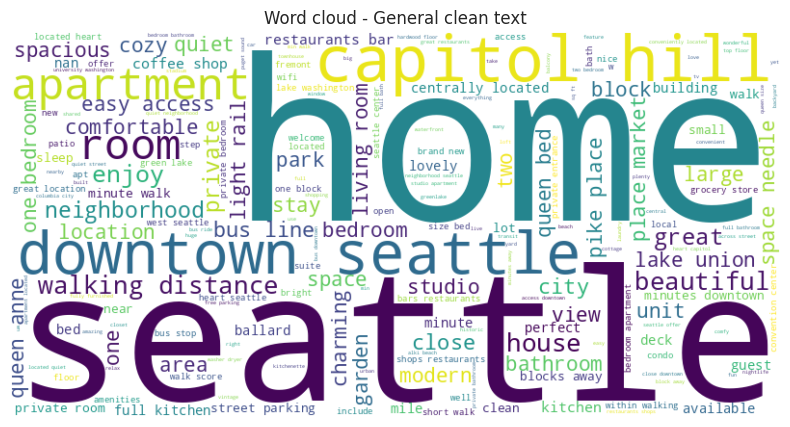

In [12]:
# Joining all texts from the 'Text_Limpo' column into a single string
text = " ".join(review for review in df.Text_Limpo)

# Defining additional stopwords
stopwords = set(STOPWORDS)

# Displaying the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(20, 5))
plt.title("Word cloud - General clean text")
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

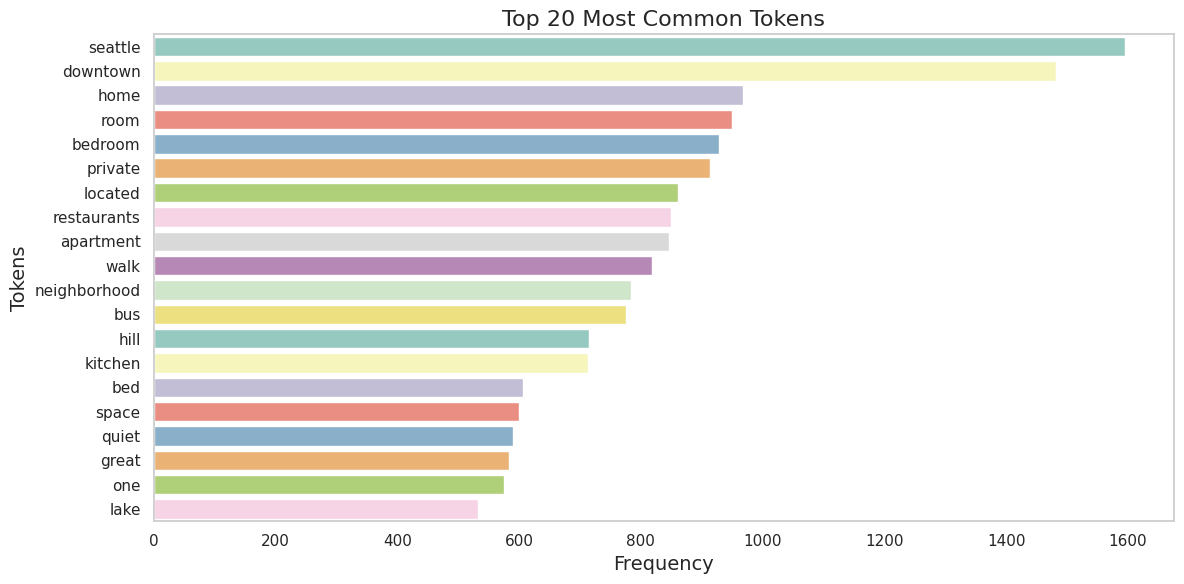

In [13]:
# Combine all tokens from the 'Tokens_SpaCy' column into a single list
all_tokens = [token for tokens in df['Tokens_SpaCy'] for token in tokens]

# Count the frequency of each token using Counter
token_counts = Counter(all_tokens)

# Get the top 20 most common tokens
common_tokens = token_counts.most_common(20)  # Limiting the result to the top 20 tokens

# Separate the tokens and their frequencies for plotting
tokens, frequencies = zip(*common_tokens)

# Create a bar plot to visualize the most frequent tokens
plt.figure(figsize=(12, 6))  # Set figure size
sns.barplot(x=list(frequencies), y=list(tokens), palette='Set3')  # Plot using seaborn with 'husl' color palette

# Set title and labels with improved readability
plt.title('Top 20 Most Common Tokens', fontsize=16)  # Title for the plot
plt.xlabel('Frequency', fontsize=14)  # X-axis label
plt.ylabel('Tokens', fontsize=14)  # Y-axis label

# Add gridlines to the x-axis for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Dashed gridlines on the x-axis

# Adjust the layout to ensure the plot elements fit well
plt.tight_layout()  

# Remove default seaborn grid
plt.grid(False)

# Display the plot
plt.show()

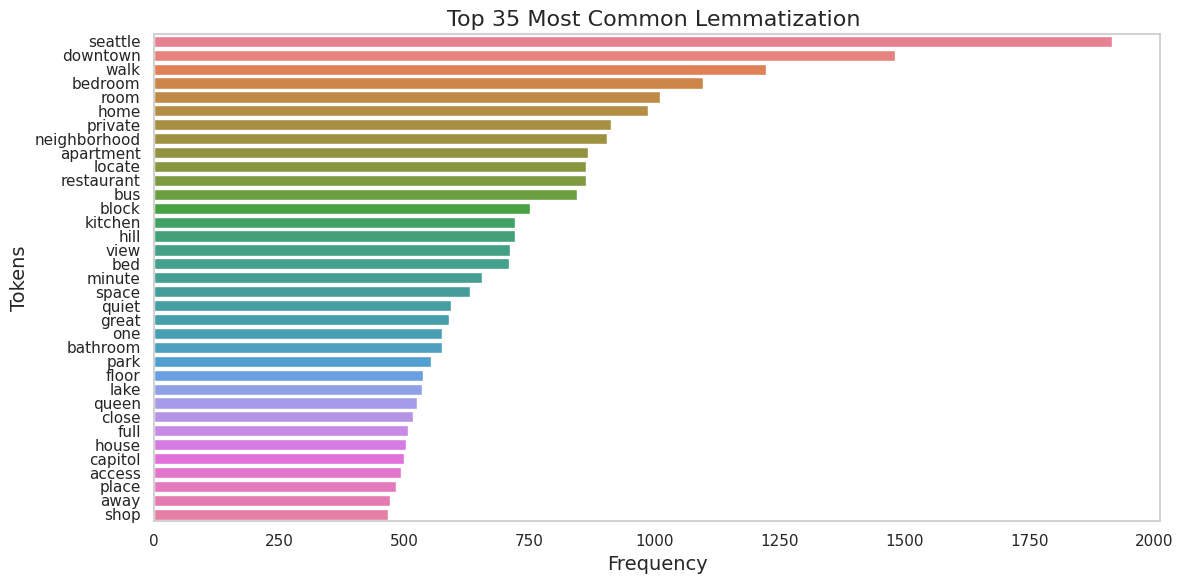

In [14]:
# Combine all tokens into a single list
all_tokens = [token for tokens in df['Lemas_SpaCy'] for token in tokens]

# Count the frequency of tokens
token_counts = Counter(all_tokens)

# Get the top 20 most common tokens
common_tokens = token_counts.most_common(35)  # Limiting to top 35

# Separate tokens and their frequencies
tokens, frequencies = zip(*common_tokens)

# Create a bar plot for the most frequent tokens
plt.figure(figsize=(12, 6))
sns.barplot(x=list(frequencies), y=list(tokens), palette='husl')  # Changed palette

# Improved title and axis labels
plt.title('Top 35 Most Common Lemmatization ', fontsize=16)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Tokens', fontsize=14)

# Add gridlines for easier reading of bar heights
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()  # Ensure layout is clean and labels fit well
plt.grid(False)
plt.show()

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 5 - Model Llama 3.3</b></div>

### What is an LLM (Large Language Model)?

A **Large Language Model (LLM)** is an advanced type of artificial intelligence designed to understand and generate human-like text. It works like a "super translator" or "conversationalist" that learns from massive amounts of text collected from the internet, books, articles, and other written content. Its goal is to answer questions, create text, translate languages, summarize information, and even provide recommendations based on specific contexts.

Think of it as a highly intelligent virtual assistant capable of responding to almost any query across a wide range of topics—that's what an LLM does. It uses the language patterns it learned during training to generate coherent and helpful responses.

### What is LLaMA?

**LLaMA** (Large Language Model Meta AI) is an LLM developed by Meta (formerly Facebook). It was designed to be more efficient and accessible, allowing researchers and developers to use this technology without requiring enormous computational resources.

Unlike larger models like GPT-4, LLaMA focuses on being "lighter" while still delivering high-quality outputs. This means it can be used for tasks such as:

- Answering questions.
- Providing recommendations.
- Summarizing texts.
- Personalizing content for different audiences.

LLaMA is highly flexible and can be fine-tuned for specific tasks, like recommending hotels, creating summaries, or answering customer queries.

In [15]:
# Ensure dependencies are up-to-date
!pip install --upgrade transformers 
!pip install --upgrade bitsandbytes

import transformers
print(transformers.__version__)

4.47.1


In [16]:
# 1. Define the path to the local model directory

# In this case, the model is stored locally at the specified path, which likely 
# contains the necessary files for a LLaMA-based model
model_name = "/kaggle/input/llama-3.2/transformers/1b/1"

# 2. Check if a GPU is available

# If a GPU is available, it will use "cuda"; otherwise, it will default to "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline 

# 3. Load the model with 8-bit quantization 
model = AutoModelForSequenceClassification.from_pretrained(model_name, 
                                                           load_in_8bit=True, 
                                                           device_map='auto')

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at /kaggle/input/llama-3.2/transformers/1b/1 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
# 4. Defining Sentiment Labels
labels = ["Positive", "Negative", "Neutral"]

# 5. Rows and columns
df.shape

(3818, 95)

In [19]:
# 6. The tokenizer is responsible for converting text into token IDs that the model can process.
# This loads the pre-trained tokenizer from the specified local model path.

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [20]:
### 7. Load the model with automatic device mapping to save memory

# The model is loaded from the pre-trained local path and uses float16 precision (half-precision) to save memory.
# The "device_map='auto'" allows for automatic distribution of the model across available hardware (e.g., GPU, CPU) to optimize memory usage.
model = AutoModelForCausalLM.from_pretrained(model_name, 
                                             torch_dtype=torch.float16, 
                                             device_map="auto")

In [21]:
# 8. Pipeline Initialization
print("Initializing the zero-shot classification pipeline...")
classifier = pipeline('zero-shot-classification',
                      model=model_name,
                      tokenizer=tokenizer)

Initializing the zero-shot classification pipeline...


Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at /kaggle/input/llama-3.2/transformers/1b/1 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 6 - Prompt engineering</b></div>

### What is Prompt Engineering?

**Prompt engineering** is the process of designing and refining input prompts to effectively guide a Large Language Model (LLM) or similar AI system to produce accurate, relevant, and high-quality outputs. It involves crafting specific instructions, questions, or examples that the model can use to understand the context and generate the desired response.

### Key Elements of Prompt Engineering:

1. **Clarity**: The prompt should clearly state what the model is expected to do. Ambiguous instructions often lead to irrelevant or incorrect responses.
   
2. **Specificity**: Providing specific details or examples in the prompt helps the model focus on the task at hand.

3. **Context**: Including background information or framing the task within a scenario improves the model's understanding of the request.

4. **Iterative Refinement**: Testing and tweaking the prompt multiple times ensures better outcomes by reducing errors and ambiguities.

### Why is Prompt Engineering Important?

Prompt engineering is crucial because the quality of the AI's output heavily depends on the input it receives. A well-designed prompt can:

- Improve the accuracy of predictions or generated content.
- Reduce the likelihood of irrelevant or nonsensical outputs.
- Adapt the AI's behavior to specific tasks or audiences.
- Enhance efficiency in using LLMs for various applications.

### Example of Prompt Engineering:

- **Basic Prompt:** "Tell me about New York."
  - Output: General information about New York.

- **Refined Prompt:** "Write a 150-word summary about New York City, focusing on its history and cultural diversity."
  - Output: A more targeted and relevant response.

Prompt engineering bridges the gap between what users need and how AI interprets and delivers those needs, making it an essential skill for maximizing the effectiveness of AI systems.

In [22]:
# Function to generate text based on a prompt
# This function takes a text prompt and generates a continuation of the text.
# The max_length parameter controls the maximum number of tokens generated.
def generate_text(prompt, max_length=150):
    # Tokenize the input prompt and move it to the model's device (e.g., GPU or CPU)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # Generate text from the model based on the input token IDs
    outputs = model.generate(inputs.input_ids, max_length=max_length)
    
    # Decode the output tokens back into a human-readable string, skipping special tokens
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [23]:
### prompt the LLM 1

# Input prompt for generating text
prompt = "What was the James Webb Telescope looking for?"

# Generate text based on the prompt
response = generate_text(prompt)

# Print the generated response
print(response)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


What was the James Webb Telescope looking for? The answer is the universe. The James Webb Telescope is a space telescope that will be launched in 2021. It will be the largest and most powerful space telescope ever built. It will be able to see the universe in unprecedented detail. It will be able to see the universe in unprecedented detail. It will be able to see the universe in unprecedented detail. It will be able to see the universe in unprecedented detail. It will be able to see the universe in unprecedented detail. It will be able to see the universe in unprecedented detail. It will be able to see the universe in unprecedented detail. It will be able to see the universe in unprecedented detail. It will be able to see the universe in


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 7 - Prompt engineering Hotel recommendation</b></div>

### Recommendation Systems Using LLMs (Large Language Models)

**What are Recommendation Systems?**

Recommendation systems are tools designed to suggest relevant items to users based on their preferences, behaviors, and interactions. Commonly seen in platforms like e-commerce, streaming services, and travel booking, these systems aim to personalize user experiences and increase engagement by presenting items the user is likely to find valuable.


**How LLMs Transform Recommendation Systems**

Traditional recommendation systems rely on algorithms like collaborative filtering, content-based filtering, or hybrid models. While effective, they often require structured data and predefined models to operate. Large Language Models (LLMs), on the other hand, offer a revolutionary approach by leveraging their ability to understand and generate human-like text, process unstructured data, and provide context-aware recommendations.

**Example: Hotel Recommendations with LLMs**

**User Query:**  
"I’m traveling to New York for business and need a hotel with strong Wi-Fi, a quiet environment, and close proximity to public transit."

**LLM Response (Generated):**  
1. **Hotel A:**  
   - *Description:* Modern business hotel with free high-speed Wi-Fi, soundproof rooms, and a 5-minute walk to the subway.  
   - *Price:* $200/night  
   - *Rating:* 4.8/5  
   
2. **Hotel B:**  
   - *Description:* Quiet boutique hotel with dedicated workspaces and excellent Wi-Fi. Close to major transit hubs.  
   - *Price:* $180/night  
   - *Rating:* 4.6/5  

3. **Hotel C:**  
   - *Description:* Luxury hotel with a serene environment, reliable Wi-Fi, and concierge services for business travelers.  
   - *Price:* $250/night  
   - *Rating:* 4.9/5  

**Challenges and Considerations**

- **Data Quality:** The effectiveness of recommendations depends on the quality of the data available to the LLM.
- **Bias Mitigation:** LLMs may inherit biases present in their training data, which could influence recommendations.
- **Computational Costs:** Running large LLMs can be resource-intensive, especially for real-time applications.

**Conclusion**

Using LLMs for recommendation systems is a powerful approach that combines the flexibility and intelligence of AI with the richness of natural language processing. This makes them ideal for applications requiring personalized, context-aware suggestions, such as travel planning, e-commerce, and entertainment services. By integrating LLMs, businesses can provide more intuitive, accurate, and engaging user experiences.

In [24]:
# Load the dataset
# Substitua pelo caminho do seu arquivo
data = pd.read_csv("/kaggle/input/seattle/listings.csv") 

# Select relevant columns
columns = ["name", "description", "neighborhood_overview", "price", 
           "review_scores_rating", "amenities", "room_type", "state"]

# 
filtered_data = data[columns]

# Handle missing values
filtered_data.dropna(subset=["name", "price", "review_scores_rating"], inplace=True)

# Normalize text columns
filtered_data["description"] = filtered_data["description"].str.lower()
filtered_data["amenities"] = filtered_data["amenities"].str.lower()

#
filtered_data.head()

#
filtered_data

,name,description,neighborhood_overview,price,review_scores_rating,amenities,room_type,state
0,Stylish Queen Anne Apartment,make your self at home in this charming one-be...,NaN,$85.00,95.0,"{tv,""cable tv"",internet,""wireless internet"",""a...",Entire home/apt,WA
1,Bright & Airy Queen Anne Apartment,chemically sensitive? we've removed the irrita...,"Queen Anne is a wonderful, truly functional vi...",$150.00,96.0,"{tv,internet,""wireless internet"",kitchen,""free...",Entire home/apt,WA
2,New Modern House-Amazing water view,new modern house built in 2013. spectacular s...,Upper Queen Anne is a charming neighborhood fu...,$975.00,97.0,"{tv,""cable tv"",internet,""wireless internet"",""a...",Entire home/apt,WA
4,Charming craftsman 3 bdm house,cozy family craftman house in beautiful neighb...,We are in the beautiful neighborhood of Queen ...,$450.00,92.0,"{tv,""cable tv"",internet,""wireless internet"",ki...",Entire home/apt,WA
5,Private unit in a 1920s mansion,we're renting out a small private unit of one ...,This part of Queen Anne has wonderful views an...,$120.00,95.0,"{""wireless internet"",""free parking on premises...",Private room,WA
...,...,...,...,...,...,...,...,...
3810,Fremont Farmhouse,our 2br/1 bath home in fremont's most fun neig...,We love that Fremont is so centrally located t...,$154.00,92.0,"{tv,""cable tv"",internet,""wireless internet"",ki...",Entire home/apt,WA
3811,Super Convenient Top Floor Apt,in the true spirit of airbnb this unit is avai...,I am equidistant to Fremont and Wallingford an...,$65.00,100.0,"{tv,""cable tv"",internet,""wireless internet"",""a...",Entire home/apt,WA
3812,OF THE TREE & CLOUDS. KID FRIENDLY!,"of the tree & clouds' ""roots"" apartment is 8 b...",It's taken me a while to figure out why Fremon...,$95.00,96.0,"{internet,""wireless internet"",kitchen,""free pa...",Entire home/apt,WA
3813,3BR Mountain View House in Seattle,our 3br/2ba house boasts incredible views of t...,We're located near lots of family fun. Woodlan...,$359.00,80.0,"{tv,""cable tv"",internet,""wireless internet"",""a...",Entire home/apt,WA


In [25]:
# Path to the base LLaMA model (adjust as needed)

# LLaMA model
base_model = "/kaggle/input/llama-3.2/transformers/3b/1"  

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [26]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load the model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model)
model = AutoModelForCausalLM.from_pretrained(base_model, 
                                             torch_dtype=torch.float16, 
                                             device_map="auto")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 8 - Prompt engineering recommendation hotel basic</b></div>

In [27]:
# Function to format hotel data into a prompt
def format_hotel_data(hotel):
    """
    Formats hotel data for model input.
    :param hotel: dictionary with hotel information.
    :return: formatted string for the model.
    """
    return (
        f"Name: {hotel['name']}\n"
        f"Location: {hotel['neighborhood_overview']}\n"
        f"Price: {hotel['price']}\n"
        f"Rating: {hotel['review_scores_rating']}\n"
        f"Amenities: {', '.join(hotel['amenities'])}\n"
    )

# Function to recommend hotels
def recommend_hotel(user_input, hotels):
    """
    Generates a hotel recommendation based on user input.
    :param user_input: string with user preferences.
    :param hotels: list of dictionaries with hotel information.
    :return: string with the recommendation.
    """
    prompt = f"Recommend a hotel based on the following user preference:\n{user_input}\n\n"
    for hotel in hotels[:10]:  # Limit the number of hotels used in the prompt
        prompt += format_hotel_data(hotel) + "\n"
    prompt += "Based on the options above, which hotel do you recommend and why?\n"

    # Tokenize and generate response
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device)  # Truncate to avoid overflow
    model.config.pad_token_id = tokenizer.eos_token_id  # Set pad token ID

    # Generate output with a limit on new tokens
    outputs = model.generate(inputs.input_ids,
                             attention_mask=inputs.attention_mask,
                             max_new_tokens=150,  # Limit for generated tokens
                             temperature=0.7)

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response

In [28]:
# Prompt
user_input = "I want a cheap hotel with good ratings near the beach."

In [29]:
# Example hotel dataset
hotels = [
    {
        "name": "Hotel Near the Beach",
        "neighborhood_overview": "Located close to the beach with easy access to downtown.",
        "price": "$75/night",
        "review_scores_rating": "4.8",
        "amenities": ["Wi-Fi", "Breakfast", "Free parking"]
    },
    {
        "name": "Budget Hotel Downtown",
        "neighborhood_overview": "In the heart of the city, ideal for business trips.",
        "price": "$50/night",
        "review_scores_rating": "4.2",
        "amenities": ["Wi-Fi", "Air conditioning"]
    },
    {
        "name": "Luxury Hotel with View",
        "neighborhood_overview": "Panoramic city views with spa and award-winning restaurant.",
        "price": "$200/night",
        "review_scores_rating": "5.0",
        "amenities": ["Spa", "Pool", "Wi-Fi", "Restaurant"]
    }
]

In [30]:
# Generate recommendation
recommendation = recommend_hotel(user_input, hotels)

# Display the recommendation
print("Model Recommendation:")
print(recommendation)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Model Recommendation:
Recommend a hotel based on the following user preference:
I want a cheap hotel with good ratings near the beach.

Name: Hotel Near the Beach
Location: Located close to the beach with easy access to downtown.
Price: $75/night
Rating: 4.8
Amenities: Wi-Fi, Breakfast, Free parking

Name: Budget Hotel Downtown
Location: In the heart of the city, ideal for business trips.
Price: $50/night
Rating: 4.2
Amenities: Wi-Fi, Air conditioning

Name: Luxury Hotel with View
Location: Panoramic city views with spa and award-winning restaurant.
Price: $200/night
Rating: 5.0
Amenities: Spa, Pool, Wi-Fi, Restaurant

Based on the options above, which hotel do you recommend and why?
```


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 9 - Prompt engineering recommendation hotel Analyzing csv</b></div>

In [31]:
# Function to format hotel data
def format_hotel_data(hotel):
    """
    Formats hotel data for model input.
    :param hotel: Dictionary with hotel information.
    :return: Formatted string.
    """
    return (
        f"Name: {hotel['name']}\n"
        f"Description: {hotel['description']}\n"
        f"Location: {hotel['neighborhood_overview']}\n"
        f"Price: {hotel['price']}\n"
        f"Rating: {hotel['review_scores_rating']}\n"
        f"Amenities: {hotel['amenities']}\n"
        f"Room Type: {hotel['room_type']}\n"
        f"State: {hotel['state']}\n"
    )

# Function to recommend hotels with a clear choice
def recommend_hotels(user_input, filtered_data, tokenizer, model, top_n=30):
    """
    Generates hotel recommendations based on user preferences.
    :param user_input: User preferences.
    :param filtered_data: DataFrame with hotel information.
    :param tokenizer: Model tokenizer.
    :param model: LLaMA model.
    :param top_n: Number of hotels to include in the prompt.
    :return: String with the recommendation.
    """

    # Prompt
    prompt = f"Recommend only one hotel based on the following user preference:\n{user_input}\n\n"

    # Include only the first 'top_n' hotels
    for _, hotel in filtered_data.head(top_n).iterrows():
        prompt += format_hotel_data(hotel) + "\n"
    
    prompt += "Based on the options above, choose only one hotel that best meets the user's preferences and explain the reason for the recommendation.\n"

    # Tokenize the prompt
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device)
    model.config.pad_token_id = tokenizer.eos_token_id

    # Generate recommendations
    outputs = model.generate(inputs.input_ids,
                             attention_mask=inputs.attention_mask,
                             max_new_tokens=300,  # Increase the limit of generated tokens
                             temperature=0.7,
                             repetition_penalty=1.2,  # Penalize repetitions
                            )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 10 - Viewing the recommendations</b></div>

In [32]:
# Recommendation 1
user_input = "I want a hotel with breakfast, good ratings, and affordable prices."

# Adjust the number of hotels in the prompt
recommendation = recommend_hotels(user_input, filtered_data, tokenizer, model, top_n=30)

# Display recommendation
print("Model Recommendation:")
print(recommendation)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Model Recommendation:
Recommend only one hotel based on the following user preference:
I want a hotel with breakfast, good ratings, and affordable prices.

Name: Stylish Queen Anne Apartment
Description: make your self at home in this charming one-bedroom apartment, centrally-located on the west side of queen anne hill.   this elegantly-decorated, completely private apartment (bottom unit of a duplex) has an open floor plan, bamboo floors, a fully equipped kitchen, a tv,  dvd player, basic cable, and a very cozy bedroom with a queen-size bed. the unit sleeps up to four (two in the bedroom and two on the very comfortable fold out couch, linens included) and includes free wifi and laundry. the apartment opens onto a private deck, complete with it's own bbq, overlooking a garden and a forest of black bamboo.    the apartment is perfectly-located just one block from the bus lines where you can catch a bus and be downtown seattle in fifteen minutes or historic ballard in ten or a quick five

In [33]:
# Recommendation 2
user_input = "I want an affordable hotel with complimentary breakfast and high ratings."

# Adjust the number of hotels in the prompt
recommendation = recommend_hotels(user_input, filtered_data, tokenizer, model, top_n=30)

# Display recommendation
print("Model Recommendation:")
print(recommendation)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Model Recommendation:
Recommend only one hotel based on the following user preference:
I want an affordable hotel with complimentary breakfast and high ratings.

Name: Stylish Queen Anne Apartment
Description: make your self at home in this charming one-bedroom apartment, centrally-located on the west side of queen anne hill.   this elegantly-decorated, completely private apartment (bottom unit of a duplex) has an open floor plan, bamboo floors, a fully equipped kitchen, a tv,  dvd player, basic cable, and a very cozy bedroom with a queen-size bed. the unit sleeps up to four (two in the bedroom and two on the very comfortable fold out couch, linens included) and includes free wifi and laundry. the apartment opens onto a private deck, complete with it's own bbq, overlooking a garden and a forest of black bamboo.    the apartment is perfectly-located just one block from the bus lines where you can catch a bus and be downtown seattle in fifteen minutes or historic ballard in ten or a quic

In [34]:
# Recommendation 3

# Recommendation 2
user_input = f"""
You are a travel recommendation assistant. Your task is to recommend the top {30} hotels based on the following user preferences:
- Price: Affordable
- Amenities: Complimentary breakfast
- Ratings: High
Filter the recommendations to match these preferences and provide a ranked list of hotels with their names, descriptions, and key features.
"""

# Adjust the number of hotels in the prompt
recommendation = recommend_hotels(user_input, filtered_data, tokenizer, model, top_n=30)

# Display recommendation
print("Model Recommendation:")
print(recommendation)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Model Recommendation:
Recommend only one hotel based on the following user preference:

You are a travel recommendation assistant. Your task is to recommend the top 30 hotels based on the following user preferences:
- Price: Affordable
- Amenities: Complimentary breakfast
- Ratings: High
Filter the recommendations to match these preferences and provide a ranked list of hotels with their names, descriptions, and key features.


Name: Stylish Queen Anne Apartment
Description: make your self at home in this charming one-bedroom apartment, centrally-located on the west side of queen anne hill.   this elegantly-decorated, completely private apartment (bottom unit of a duplex) has an open floor plan, bamboo floors, a fully equipped kitchen, a tv,  dvd player, basic cable, and a very cozy bedroom with a queen-size bed. the unit sleeps up to four (two in the bedroom and two on the very comfortable fold out couch, linens included) and includes free wifi and laundry. the apartment opens onto a p

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 11 - Conclusion</b></div>

### Conclusion for the Hotel Recommendation Project

This project successfully demonstrates how to use a **Large Language Model (LLM)** for generating personalized hotel recommendations based on user preferences. By leveraging prompt engineering and a pre-trained model, we have achieved a system capable of dynamically understanding and responding to user inputs.

### Key Achievements:

1. **Dynamic Personalization:**
   - Users can provide specific preferences (e.g., price, amenities, ratings), and the system generates recommendations tailored to those needs.
   - The LLM provides a detailed description of each recommendation, including key features like price, location, and amenities.

2. **Efficient Data Filtering:**
   - The system filters and structures hotel data into a format suitable for LLMs, ensuring the model processes relevant information efficiently.

3. **Natural Language Interaction:**
   - The recommendations are presented in a human-readable format, making them easy for users to understand and act upon.

4. **Flexibility with Complex Queries:**
   - The system handles a variety of user queries, from budget-conscious travelers to those seeking luxury accommodations, showcasing the versatility of LLMs in decision-support applications.


### Observations:

- The **prompt engineering** ensures that the model comprehends the user’s requirements and provides coherent, context-aware recommendations.
- Including detailed hotel information (name, description, price, location, amenities) allows users to make informed decisions without needing to consult additional resources.

### Challenges and Future Improvements:

1. **Data Completeness:**
   - Some hotel entries had missing or incomplete data (e.g., "Location: nan"). Cleaning and enriching the dataset could improve the quality of recommendations.

2. **Scalability:**
   - While the system currently handles a small dataset efficiently, optimizing for larger datasets and higher numbers of recommendations (e.g., `top_n=50+`) may require more robust tokenization and computational resources.

3. **Model Tuning:**
   - Fine-tuning the model on domain-specific data could further improve the relevance and accuracy of the recommendations.

4. **Multi-Language Support:**
   - Adding multilingual capabilities would broaden the system’s usability for international users.

5. **Additional Features:**
   - Implementing features like real-time availability checks or direct booking links could enhance the overall utility of the system.

### Final Recommendations:

- **For Deployment:** Integrate the system into a web or mobile interface for end-users, allowing them to input preferences and view recommendations interactively.

- **For Further Research:** Explore incorporating user feedback loops to refine recommendations over time.

- **For Business Applications:** Use this approach to enhance customer experience in travel, e-commerce, or other recommendation-heavy domains.

This project highlights the transformative potential of LLMs in personalized recommendation systems, bridging the gap between user needs and actionable insights. With further refinement, it can serve as a valuable tool in the travel and hospitality industry.